In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

In [7]:
df = pd.read_csv("habits.csv")

In [8]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [9]:
df.shape

(1000, 16)

In [10]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [12]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [13]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df = df.drop_duplicates()

In [16]:
numerical_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(include='object').columns

print("Numerical Columns:")
print(list(numerical_columns))

print("\nCategorical Columns:")
print(list(categorical_columns))

Numerical Columns:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']

Categorical Columns:
['student_id', 'gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


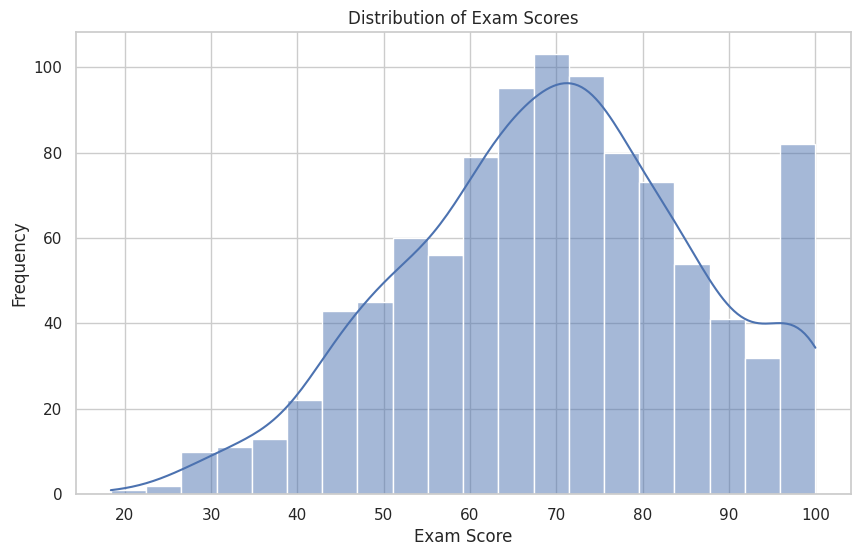

In [17]:
plt.figure(figsize=(10,6))

sns.histplot(df['exam_score'], bins=20, kde=True)

plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.show()

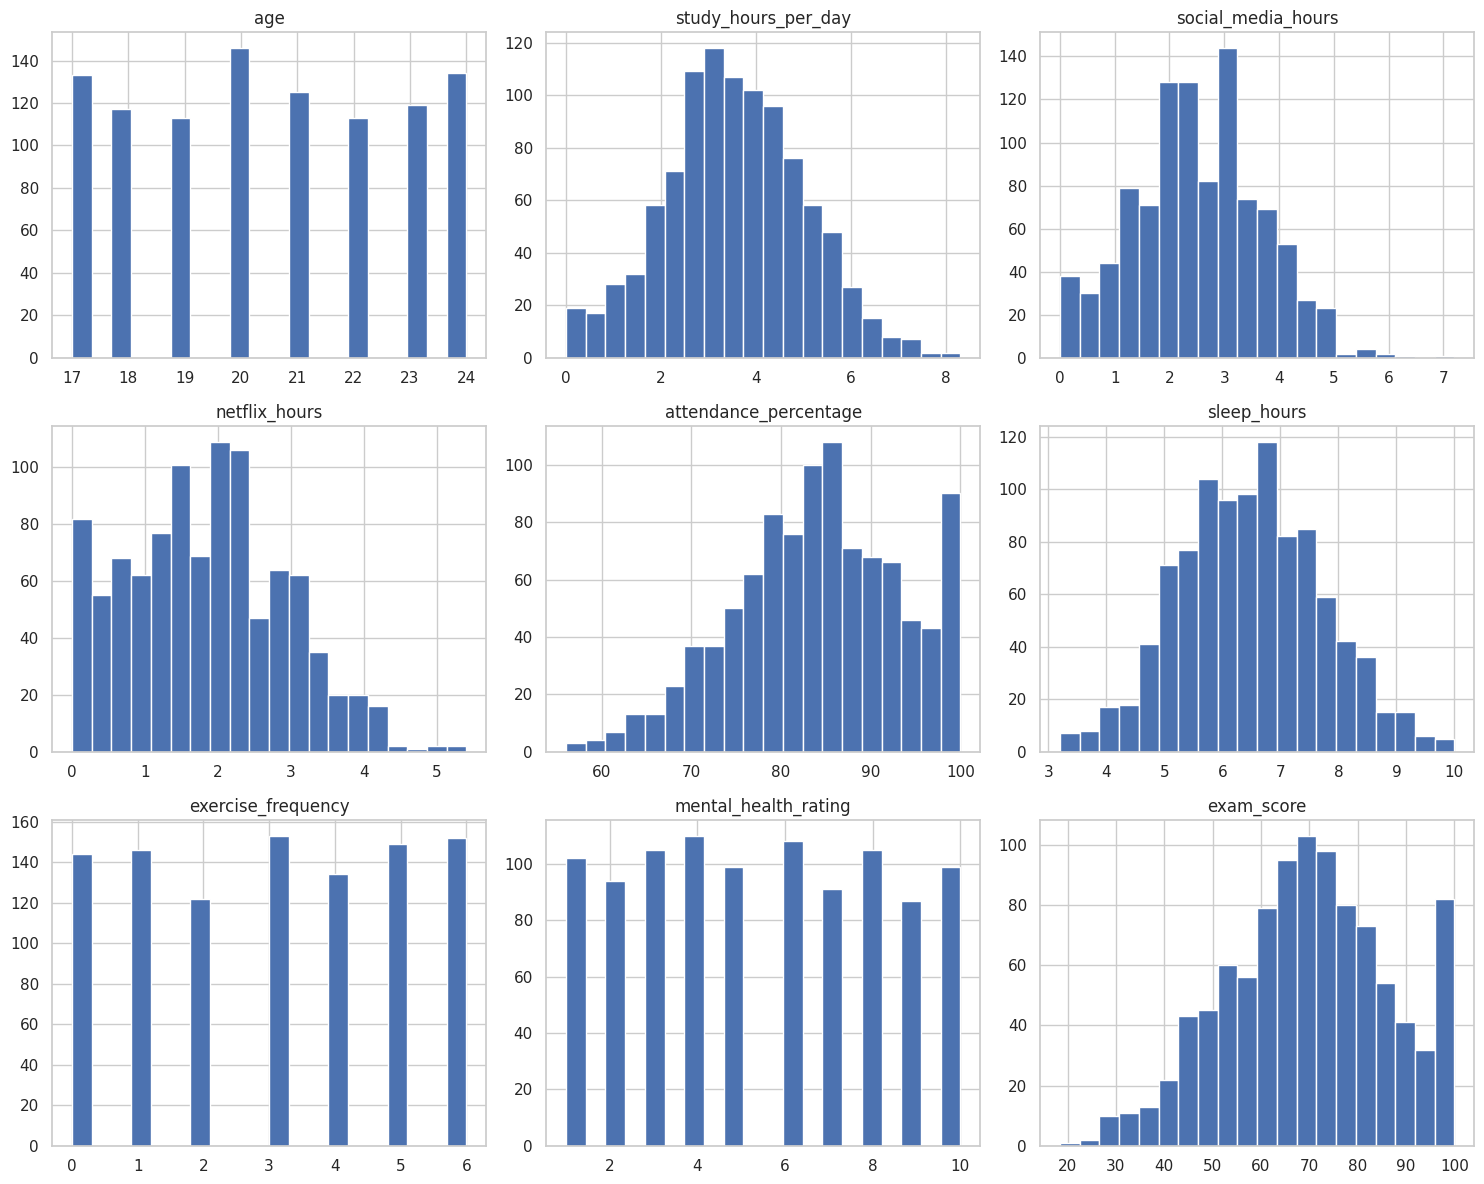

In [18]:
df[numerical_columns].hist(
    figsize=(15,12),
    bins=20
)

plt.tight_layout()
plt.show()

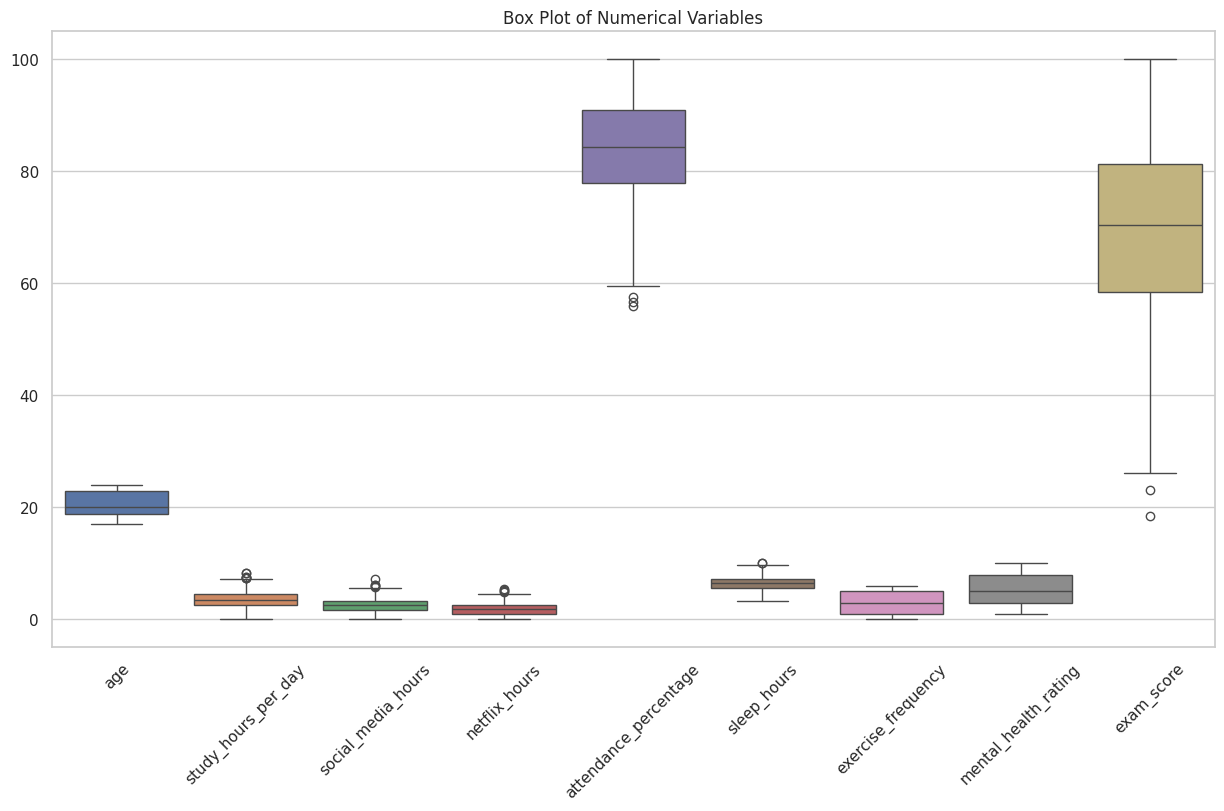

In [19]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df[numerical_columns])

plt.title('Box Plot of Numerical Variables')
plt.xticks(rotation=45)
plt.show()

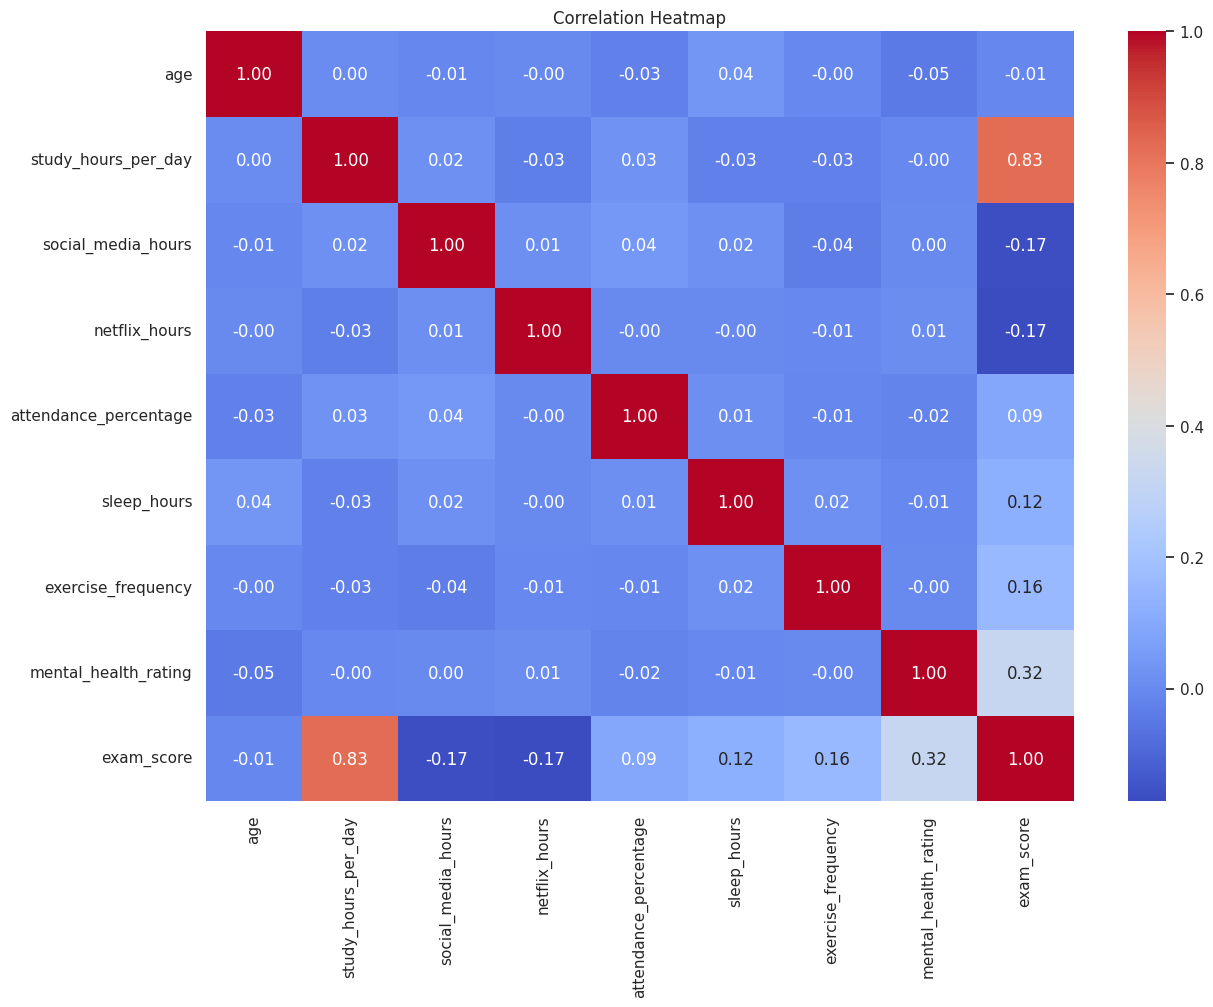

In [21]:
plt.figure(figsize=(14,10))

correlation = df[numerical_columns].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

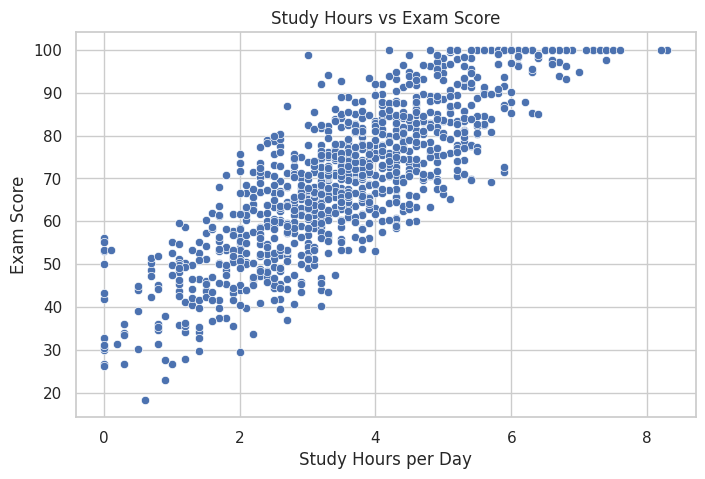

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='study_hours_per_day',
    y='exam_score'
)

plt.title('Study Hours vs Exam Score')
plt.xlabel('Study Hours per Day')
plt.ylabel('Exam Score')
plt.show()

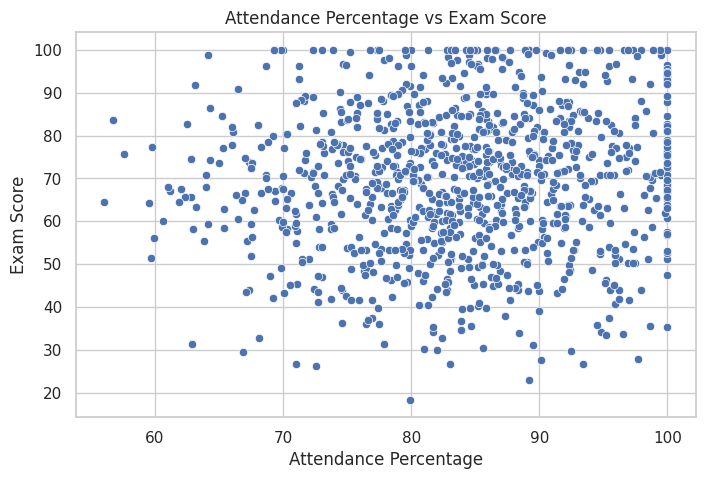

In [23]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='attendance_percentage',
    y='exam_score'
)

plt.title('Attendance Percentage vs Exam Score')
plt.xlabel('Attendance Percentage')
plt.ylabel('Exam Score')
plt.show()

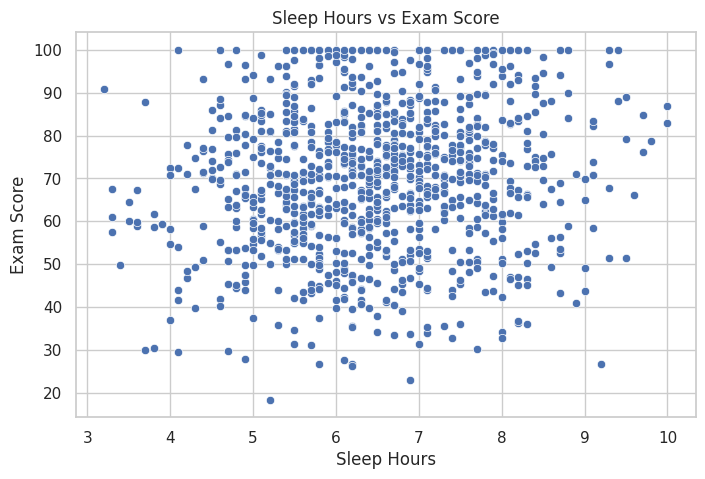

In [24]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='sleep_hours',
    y='exam_score'
)

plt.title('Sleep Hours vs Exam Score')
plt.xlabel('Sleep Hours')
plt.ylabel('Exam Score')
plt.show()

In [25]:
y = df['exam_score']

In [26]:
X = df.drop('exam_score', axis=1)

In [27]:
X.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No


In [28]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

print("Numeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numeric Features:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']

Categorical Features:
['student_id', 'gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (800, 15)
Testing Data: (200, 15)


In [31]:
linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

In [32]:
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'study_hours_per_day',
                                                   'social_media_hours',
                                                   'netflix_hours',
                                                   'attendance_percentage',
                                                   'sleep_hours',
                                                   'exercise_frequency',
                                                   'mental_health_rating']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['student_id', 'gender',
                                                   'part_time_job',
                                                   'diet_quality',
                                                   'parental_education_level',
                                                   'internet_quality',
                                                   'extracurricular_participation'])])),
                ('model', LinearRegression())])

In [33]:
y_pred = linear_model.predict(X_test)

In [34]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 4.189850103558331


In [35]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 26.48816407915977


In [36]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 5.146665335842206


In [37]:
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

R² Score: 0.8967037497212884


In [38]:
print("Linear Regression Performance")
print("-----------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Linear Regression Performance
-----------------------------
MAE : 4.189850103558331
MSE : 26.48816407915977
RMSE: 5.146665335842206
R²  : 0.8967037497212884


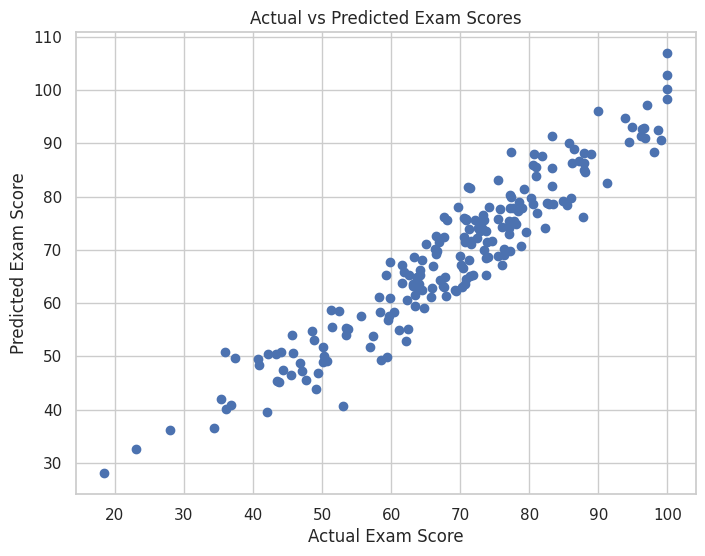

In [39]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Actual vs Predicted Exam Scores')

plt.show()

In [40]:
df['pass_fail'] = np.where(
    df['exam_score'] >= 50,
    1,
    0
)

In [41]:
df['pass_fail'].value_counts()

,count
pass_fail,
1,869
0,131


In [42]:
df['pass_fail_label'] = df['pass_fail'].map({
    0: 'Fail',
    1: 'Pass'
})

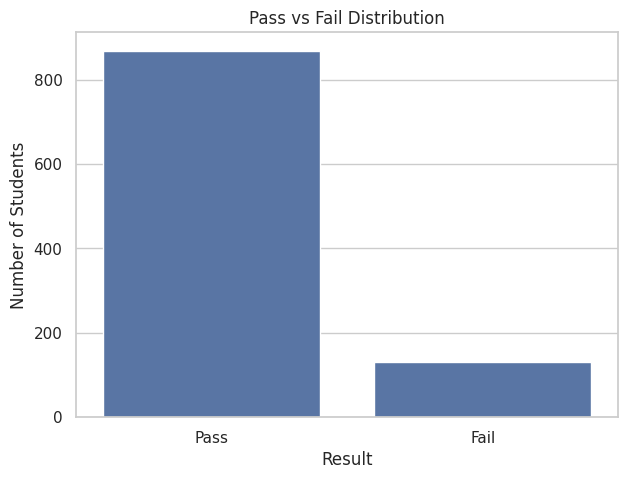

In [43]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='pass_fail_label'
)

plt.title('Pass vs Fail Distribution')
plt.xlabel('Result')
plt.ylabel('Number of Students')

plt.show()

In [44]:
X_class = df.drop(
    ['exam_score', 'pass_fail', 'pass_fail_label'],
    axis=1
)

y_class = df['pass_fail']

In [45]:
numeric_class_features = X_class.select_dtypes(
    include=np.number
).columns.tolist()

categorical_class_features = X_class.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

In [46]:
classification_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_class_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'),
         categorical_class_features)
    ]
)

In [47]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

In [48]:
classification_model = Pipeline(
    steps=[
        ('preprocessor', classification_preprocessor),
        ('model', LogisticRegression(max_iter=1000))
    ]
)

In [49]:
classification_model.fit(
    X_train_c,
    y_train_c
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'study_hours_per_day',
                                                   'social_media_hours',
                                                   'netflix_hours',
                                                   'attendance_percentage',
                                                   'sleep_hours',
                                                   'exercise_frequency',
                                                   'mental_health_rating']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['student_id', 'gender',
                                                   'part_time_job',
                                                   'diet_quality',
                                                   'parental_education_level',
                                                   'internet_quality',
                                                   'extracurricular_participation'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [50]:
y_pred_c = classification_model.predict(X_test_c)

In [51]:
accuracy = accuracy_score(y_test_c, y_pred_c)
print("Accuracy:", accuracy)

Accuracy: 0.955


In [52]:
precision = precision_score(y_test_c, y_pred_c)
print("Precision:", precision)

Precision: 0.9714285714285714


In [53]:
recall = recall_score(y_test_c, y_pred_c)
print("Recall:", recall)

Recall: 0.9770114942528736


In [55]:
f1 = f1_score(y_test_c, y_pred_c)
print("F1 Score:", f1)

F1 Score: 0.9742120343839542


In [56]:
print("Classification Performance")
print("--------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Classification Performance
--------------------------
Accuracy : 0.955
Precision: 0.9714285714285714
Recall   : 0.9770114942528736
F1 Score : 0.9742120343839542


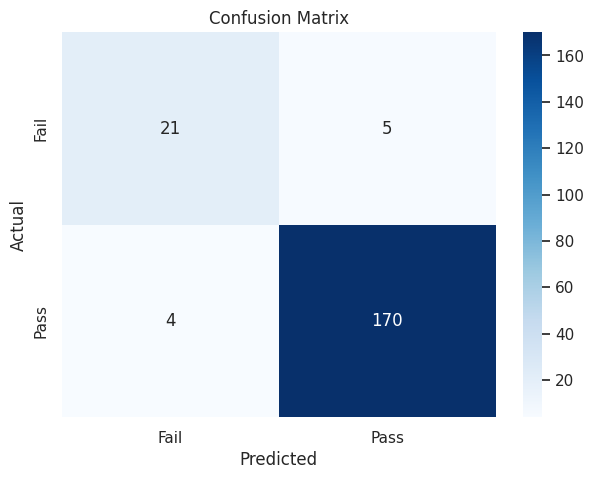

In [57]:
cm = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fail', 'Pass'],
    yticklabels=['Fail', 'Pass']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [58]:
print(
    classification_report(
        y_test_c,
        y_pred_c,
        target_names=['Fail', 'Pass']
    )
)

              precision    recall  f1-score   support

        Fail       0.84      0.81      0.82        26
        Pass       0.97      0.98      0.97       174

    accuracy                           0.95       200
   macro avg       0.91      0.89      0.90       200
weighted avg       0.95      0.95      0.95       200



In [59]:
train_pred = linear_model.predict(X_train)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, y_pred)

print("Training R²:", train_r2)
print("Testing R² :", test_r2)

Training R²: 0.9999999999811393
Testing R² : 0.8967037497212884


In [60]:
train_class_pred = classification_model.predict(X_train_c)

train_accuracy = accuracy_score(
    y_train_c,
    train_class_pred
)

test_accuracy = accuracy_score(
    y_test_c,
    y_pred_c
)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)

Training Accuracy: 0.98
Testing Accuracy : 0.955


Five Key Insights

1. Study habits: Study hours per day show a relationship with exam performance. Students who spend more time studying tend to have different exam-score patterns compared with students who study less.

2. Attendance: Attendance percentage is an important variable to investigate because students with better attendance may show stronger academic performance.

3. Lifestyle factors: Sleep, social media usage, Netflix usage, and exercise provide useful information about how lifestyle patterns are associated with student performance.

4. Student wellbeing: Mental health rating can provide additional information about student performance and should be considered alongside academic and lifestyle variables.

5. Machine learning prediction: The regression model demonstrates how multiple student-related factors can be used together to predict exam scores, while the classification model can identify whether a student is likely to pass or fail using the 50-mark threshold.

Conclusion

This project followed a complete machine learning workflow for analyzing and predicting student performance. The analysis began with exploratory data analysis to understand numerical and categorical variables, distributions, missing values, correlations, relationships, and potential outliers.

Linear Regression was then used to predict exam_score, and its performance was evaluated using MAE, MSE, RMSE, and R² score. A classification problem was also created by defining students scoring 50 or above as Pass and students scoring below 50 as Fail. Logistic Regression was used for classification and evaluated using accuracy, precision, recall, F1-score, and a confusion matrix.

Finally, training and testing performance were compared to identify possible overfitting or underfitting. Overall, the analysis demonstrates how machine learning can be used to understand factors associated with student performance and build predictive models for academic outcomes.